### Import all required packages

In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

### Check hardware

In [18]:
if torch.cuda.is_available():
    device = torch.device("cuda")

elif torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cpu")

if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

elif device.type == "mps":
    # print(f"  Memory: {torch.mps.driver_allocated_memory() / 1e9:.2f} GB")
    print("  GPU: Apple Silicon")

else:
    print("CPU")

  GPU: Apple Silicon


### Load dataset

In [32]:
from pathlib import Path
import os

candidates = [
    Path("data/raw"),
    Path("./data/raw"),
    Path("../data/raw"),
]

data_root = None
for c in candidates:
    if (c / "ascii" / "lines.txt").exists():
        data_root = c.resolve()
        break

if data_root is None:
    raise FileNotFoundError("Не найден lines.txt. Ожидается data/raw/ascii/lines.txt")

print(f"Используем датасет: {data_root}")
lines_file = data_root / "ascii" / "lines.txt"

# Парсим файл разметки
# Формат: id status gray comps x y w h transcription
# Пример id: a01-000u-00

data_samples = []
missing_images = 0
skipped_err = 0
skipped_short = 0

with open(lines_file, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split()
        if len(parts) < 9:
            skipped_short += 1
            continue

        line_id = parts[0]                # a01-000u-00
        status = parts[1]                 # ok / err
        bbox_x, bbox_y, bbox_w, bbox_h = map(int, parts[4:8])

        if status == "err":
            skipped_err += 1
            continue

        text = " ".join(parts[8:]).replace("|", " ").strip()
        if not text:
            continue

        # В IAM line-изображения лежат так:
        # lines/a01/a01-000u/a01-000u-00.png
        form_prefix = line_id.split("-")[0]            # a01
        form_page = "-".join(line_id.split("-")[:2])  # a01-000u
        img_path = data_root / "lines" / form_prefix / form_page / f"{line_id}.png"

        if not img_path.exists():
            missing_images += 1
            continue

        data_samples.append(
            {
                "id": line_id,
                "text": text,
                "img_path": str(img_path),
                "bbox": (bbox_x, bbox_y, bbox_w, bbox_h),
            }
        )

print(f"✓ Загружено {len(data_samples)} примеров")
print(f"  Пропущено status=err: {skipped_err}")
print(f"  Пропущено коротких строк: {skipped_short}")
print(f"  Изображения не найдены: {missing_images}")

if data_samples:
    print("✓ Первый пример:")
    print(f"  ID: {data_samples[0]['id']}")
    print(f"  Text: {data_samples[0]['text']}")
    print(f"  Image: {data_samples[0]['img_path']}")
    print(f"  Bbox: {data_samples[0]['bbox']}")
else:
    print("⚠ Не найдено ни одного валидного примера. Проверьте путь и структуру папок IAM.")

Используем датасет: /Users/andrew/Documents/Programming/gitrepos/Handwriting_OCR-spbu/data/raw
✓ Загружено 11344 примеров
  Пропущено status=err: 2009
  Пропущено коротких строк: 0
  Изображения не найдены: 0
✓ Первый пример:
  ID: a01-000u-00
  Text: A MOVE to stop Mr. Gaitskell from
  Image: /Users/andrew/Documents/Programming/gitrepos/Handwriting_OCR-spbu/data/raw/lines/a01/a01-000u/a01-000u-00.png
  Bbox: (408, 746, 1661, 89)


Статистика текстов:
  Min length: 1
  Max length: 93
  Avg length: 43.0

✓ Уникальных символов: 79
  Символы: [' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Статистика изображений:
  Height: min=65, max=200, avg=115
  Width: min=363, max=2087, avg=1782


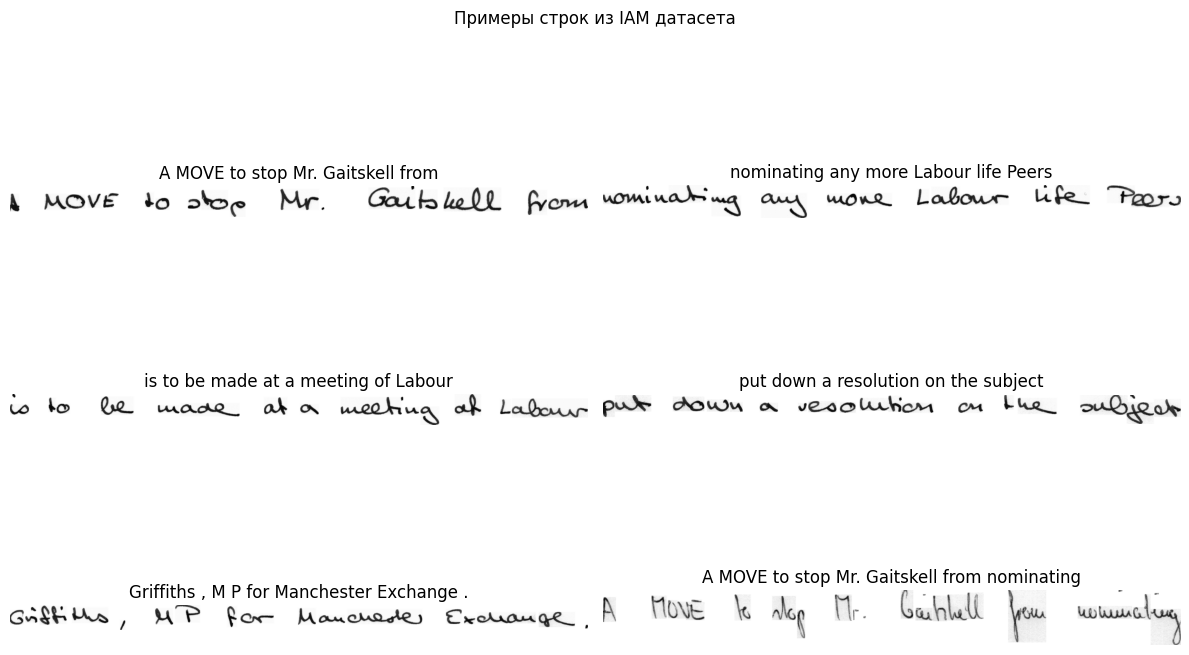

In [24]:
# Исследуем датасет
from PIL import Image
import matplotlib.pyplot as plt

# Статистика по текстам
text_lengths = [len(s['text']) for s in data_samples]
print(f"Статистика текстов:")
print(f"  Min length: {min(text_lengths)}")
print(f"  Max length: {max(text_lengths)}")
print(f"  Avg length: {np.mean(text_lengths):.1f}")

# Найдём все уникальные символы
all_chars = set()
for sample in data_samples:
    all_chars.update(sample['text'])

print(f"\n✓ Уникальных символов: {len(all_chars)}")
print(f"  Символы: {sorted(all_chars)}")

# Посмотрим на размеры изображений
img_widths = []
img_heights = []
for i, sample in enumerate(data_samples[:100]):  # Проверяем первые 100
    try:
        img = Image.open(sample['img_path'])
        img_widths.append(img.width)
        img_heights.append(img.height)
    except:
        pass

if img_widths:
    print(f"\nСтатистика изображений:")
    print(f"  Height: min={min(img_heights)}, max={max(img_heights)}, avg={np.mean(img_heights):.0f}")
    print(f"  Width: min={min(img_widths)}, max={max(img_widths)}, avg={np.mean(img_widths):.0f}")

# Визуализируем несколько примеров
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for idx in range(min(6, len(data_samples))):
    ax = axes[idx // 2, idx % 2]
    try:
        img = Image.open(data_samples[idx]['img_path'])
        ax.imshow(img, cmap='gray')
        ax.set_title(data_samples[idx]['text'][:50])
        ax.axis('off')
    except:
        ax.text(0.5, 0.5, 'Failed to load', ha='center', va='center')

plt.suptitle('Примеры строк из IAM датасета')
plt.tight_layout()
plt.show()


In [33]:
# CharacterMapper: кодирование текста
# Задача: преобразовать текст в числа и обратно

class CharacterMapper:
    """Маппер для преобразования символов ↔ индексы"""
    
    def __init__(self, samples):
        """Собрать все уникальные символы из датасета"""
        # Собираем все уникальные символы
        unique_chars = set()
        for sample in samples:
            unique_chars.update(sample['text'])
        
        # Сортируем для консистентности
        self.chars = sorted(list(unique_chars))
        
        # Создаём маппинги
        # Индекс 0 зарезервирован для CTC "пустого" символа (blank)
        self.char2idx = {c: i + 1 for i, c in enumerate(self.chars)}
        self.idx2char = {i + 1: c for i, c in enumerate(self.chars)}
        self.idx2char[0] = ''  # blank token для CTC
        
        self.num_classes = len(self.chars) + 1  # +1 для blank
    
    def encode(self, text):
        """Текст → список индексов"""
        indices = []
        for c in text:
            if c in self.char2idx:
                indices.append(self.char2idx[c])
        return indices
    
    def decode(self, indices):
        """Список индексов → текст (с удалением дубликатов подряд)"""
        chars = []
        prev_idx = None
        for idx in indices:
            # В CTC декодировании:
            # 1. Пропускаем blank (0)
            # 2. Удаляем повторяющиеся символы подряд
            if idx != 0 and idx != prev_idx and idx in self.idx2char:
                chars.append(self.idx2char[idx])
            prev_idx = idx
        return ''.join(chars)

# Создаём маппер
char_mapper = CharacterMapper(data_samples)
print(f"✓ CharacterMapper: {char_mapper.num_classes} классов")
print(f"  Символы: {char_mapper.chars[:20]}...")

# Тестируем
test_text = "Hello"
encoded = char_mapper.encode(test_text)
decoded = char_mapper.decode(encoded)
print(f"\nТест: '{test_text}' → {encoded} → '{decoded}'")


✓ CharacterMapper: 80 классов
  Символы: [' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5']...

Тест: 'Hello' → [35, 58, 65, 65, 68] → 'Helo'


In [26]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class IAMDataset(Dataset):
    """
    Датасет для IAM lines.
    
    Что происходит:
    1. Загружает изображение (PNG)
    2. Конвертирует в grayscale
    3. Нормализует пиксели
    4. Кодирует текст в индексы через CharacterMapper
    """
    
    def __init__(self, samples, char_mapper, img_height=64):
        """
        Args:
            samples: список словарей с 'img_path' и 'text'
            char_mapper: CharacterMapper для кодирования текста
            img_height: высота, к которой ресайзить изображение
        """
        self.samples = samples
        self.char_mapper = char_mapper
        self.img_height = img_height
    
    def __len__(self):
        """Сколько всего примеров в датасете"""
        return len(self.samples)
    
    def __getitem__(self, idx):
        """Получить один пример: (image, targets, text)"""
        sample = self.samples[idx]
        
        # 1. Загружаем и обрабатываем изображение
        img = Image.open(sample['img_path']).convert('L')  # L = grayscale
        
        # 2. Ресайз: сохраняем aspect ratio, высота = img_height
        w, h = img.size  # (ширина, высота)
        new_w = int(self.img_height * (w / h))
        img = img.resize((new_w, self.img_height), Image.Resampling.LANCZOS)
        
        # 3. Нормализация пикселей: [0, 255] → [-1, 1]
        img_array = np.array(img, dtype=np.float32) / 255.0  # [0, 1]
        img_array = (img_array - 0.5) / 0.5  # [-1, 1]
        
        # 4. В PyTorch формат: (1, height, width) - 1 channel (grayscale)
        img_tensor = torch.FloatTensor(img_array).unsqueeze(0)
        
        # 5. Кодируем текст в индексы
        target_indices = self.char_mapper.encode(sample['text'])
        target_tensor = torch.LongTensor(target_indices)
        
        return {
            'image': img_tensor,          # (1, height, width)
            'target': target_tensor,      # (seq_len,) - длина переменная
            'text': sample['text'],       # оригинальный текст
            'img_path': sample['img_path']
        }


def collate_fn(batch):
    """
    Функция для объединения примеров в батч.
    
    Проблема: изображения разной ширины!
    Решение: padding — добиваем нулями до максимальной ширины в батче
    """
    
    images = [item['image'] for item in batch]
    targets = [item['target'] for item in batch]
    texts = [item['text'] for item in batch]
    
    # Находим максимальную ширину в батче
    max_width = max(img.shape[2] for img in images)  # img.shape = (1, height, width)
    batch_size = len(images)
    height = images[0].shape[1]
    
    # Создаём тензор для батча с паддингом
    padded_images = torch.zeros(batch_size, 1, height, max_width)
    input_lengths = []  # Реальные длины до паддинга (для CTC)
    
    for i, img in enumerate(images):
        w = img.shape[2]
        padded_images[i, :, :, :w] = img  # Копируем изображение в левую часть
        input_lengths.append(w)
    
    # Объединяем все targets в один тензор
    # Нужно также хранить их длины для CTC Loss
    target_lengths = torch.LongTensor([len(t) for t in targets])
    targets_concatenated = torch.cat([t for t in targets])  # Объединяем все индексы
    
    return {
        'images': padded_images,              # (batch_size, 1, height, max_width)
        'targets': targets_concatenated,      # (total_chars,) - все индексы вместе
        'target_lengths': target_lengths,     # (batch_size,) - длина каждого текста
        'input_lengths': torch.LongTensor(input_lengths),  # (batch_size,) - длина каждого изображения
        'texts': texts                        # (batch_size,) - оригинальные тексты
    }


# Создаём датасет
print("Создание датасета...")
full_dataset = IAMDataset(data_samples, char_mapper, img_height=64)

# Для теста: берём первые 100 примеров в train и остаток в val
train_size = min(100, len(full_dataset) // 2)
val_size = len(full_dataset) - train_size
from torch.utils.data import random_split
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Создаём DataLoaders
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                          collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, 
                        collate_fn=collate_fn, num_workers=0)

print(f"✓ Train: {len(train_dataset)} примеров ({len(train_loader)} батчей)")
print(f"✓ Val: {len(val_dataset)} примеров ({len(val_loader)} батчей)")

# Тестируем DataLoader
print("\nТест батча:")
batch = next(iter(train_loader))
print(f"  images shape: {batch['images'].shape}")
print(f"  targets shape: {batch['targets'].shape}")
print(f"  target_lengths: {batch['target_lengths']}")
print(f"  input_lengths: {batch['input_lengths']}")
print(f"  texts: {batch['texts'][0]}")


Создание датасета...
✓ Train: 100 примеров (25 батчей)
✓ Val: 11244 примеров (2811 батчей)

Тест батча:
  images shape: torch.Size([4, 1, 64, 982])
  targets shape: torch.Size([166])
  target_lengths: tensor([40, 45, 37, 44])
  input_lengths: tensor([776, 974, 982, 874])
  texts: strong , energetic man with a gentle and


In [37]:
class CRNN(nn.Module):
    """
    CNN-BiLSTM-CTC модель для распознавания рукописного текста.

    Архитектура:
    1. CNN: извлечение признаков из изображения
    2. BiLSTM: моделирование последовательности признаков
    3. Linear слой: преобразование в вероятности классов

    Входные данные: изображение (1, 64, variable_width)
    Выходные данные: (batch, seq_len, num_classes)
    """

    def __init__(self, img_height=64, num_chars=80, hidden_size=256, num_layers=2):
        super(CRNN, self).__init__()

        # === CNN часть: извлечение признаков ===
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(512, 512, kernel_size=2),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )

        # LazyLinear избавляет от ручного расчета c*h после CNN
        self.map2seq = nn.LazyLinear(hidden_size)

        self.rnn = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_size * 2, num_chars + 1)

    def forward(self, x):
        conv = self.cnn(x)
        b, c, h, w = conv.size()

        # Делаем ширину временной осью: (batch, width, channels*height)
        conv = conv.permute(0, 3, 1, 2).reshape(b, w, c * h)

        seq = self.map2seq(conv)
        rnn_out, _ = self.rnn(seq)
        output = self.fc(rnn_out)
        return torch.nn.functional.log_softmax(output, dim=2)


# Создаём модель
model = CRNN(
    img_height=64,
    num_chars=len(char_mapper.chars),
    hidden_size=256,
    num_layers=2,
)
model = model.to(device)

# Подсчитываем параметры после первого форварда, иначе Lazy слои "неинициализированы"
with torch.no_grad():
    _ = model(torch.zeros(1, 1, 64, 256, device=device))

num_params = sum(p.numel() for p in model.parameters())
print("✓ CRNN модель создана")
print(f"  Параметров: {num_params:,}")
print(f"  Device: {device}")

✓ CRNN модель создана
  Параметров: 8,617,424
  Device: mps


In [38]:
def decode_predictions(outputs, char_mapper):
    """
    Преобразуем выход модели в текст.

    Args:
        outputs: (batch, seq_len, num_classes) - log probabilities
        char_mapper: CharacterMapper

    Returns:
        List[str] - декодированные тексты
    """
    _, max_indices = torch.max(outputs, dim=2)
    predictions = []
    for seq in max_indices:
        text = char_mapper.decode(seq.cpu().numpy().tolist())
        predictions.append(text)
    return predictions


def _ctc_input_lengths_from_padded_widths(widths, max_t):
    # После текущего CNN по ширине: /2, /2, затем kernel=2 => приблизительно w//4 - 1
    lens = (widths // 4) - 1
    lens = torch.clamp(lens, min=1, max=max_t)
    return lens


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = len(train_loader)

    for batch_idx, batch in enumerate(train_loader):
        images = batch['images'].to(device)
        targets = batch['targets'].to(device)
        target_lengths = batch['target_lengths'].to(device)
        raw_widths = batch['input_lengths'].to(device)

        outputs = model(images)  # (batch, seq_len, num_classes)
        input_lengths = _ctc_input_lengths_from_padded_widths(raw_widths, outputs.size(1))

        outputs_ctc = outputs.permute(1, 0, 2)
        loss = criterion(outputs_ctc, targets, input_lengths, target_lengths)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx + 1}/{num_batches}, Loss: {loss.item():.4f}")

    return total_loss / max(1, num_batches)


def validate(model, val_loader, criterion, char_mapper, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_ground_truths = []

    with torch.no_grad():
        for batch in val_loader:
            images = batch['images'].to(device)
            targets = batch['targets'].to(device)
            target_lengths = batch['target_lengths'].to(device)
            raw_widths = batch['input_lengths'].to(device)
            texts = batch['texts']

            outputs = model(images)
            input_lengths = _ctc_input_lengths_from_padded_widths(raw_widths, outputs.size(1))

            outputs_ctc = outputs.permute(1, 0, 2)
            loss = criterion(outputs_ctc, targets, input_lengths, target_lengths)
            total_loss += loss.item()

            predictions = decode_predictions(outputs, char_mapper)
            all_predictions.extend(predictions)
            all_ground_truths.extend(texts)

    return total_loss / max(1, len(val_loader)), all_predictions, all_ground_truths


print("✓ Функции обучения готовы")

✓ Функции обучения готовы


In [35]:
import torch.optim as optim
from torch.utils.data import Subset

# Ускоряем эксперименты: ограничиваем размеры train/val для быстрых итераций
MAX_TRAIN_SAMPLES = 2000
MAX_VAL_SAMPLES = 400

if len(train_dataset) > MAX_TRAIN_SAMPLES:
    train_indices = torch.randperm(len(train_dataset))[:MAX_TRAIN_SAMPLES].tolist()
    train_dataset = Subset(train_dataset, train_indices)

if len(val_dataset) > MAX_VAL_SAMPLES:
    val_indices = torch.randperm(len(val_dataset))[:MAX_VAL_SAMPLES].tolist()
    val_dataset = Subset(val_dataset, val_indices)

batch_size = 4
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

print(f"Train subset: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val subset: {len(val_dataset)} samples, {len(val_loader)} batches")

Train subset: 100 samples, 25 batches
Val subset: 400 samples, 100 batches


In [40]:
# === Гиперпараметры ===
EPOCHS = 5  # Для теста: небольшое количество эпох
LEARNING_RATE = 0.001
BATCH_SIZE = 4

# На MPS CTCLoss пока не поддержан -> обучаем на CPU
train_device = device
if device.type == "mps":
    print("⚠ CTCLoss не поддерживается на MPS в этой версии PyTorch. Переключаем обучение на CPU.")
    train_device = torch.device("cpu")
    model = model.to(train_device)

# Обновляем глобальный device, чтобы инференс использовал то же устройство
device = train_device

# === Loss и Optimizer ===
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# === Для отслеживания метрик ===
history = {
    'train_loss': [],
    'val_loss': [],
    'val_predictions': []
}

print(f"{'='*60}")
print(f"Начало обучения: {EPOCHS} эпох, batch_size={BATCH_SIZE}")
print(f"Device: {device}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'-'*60}")
    print(f"Эпоха {epoch}/{EPOCHS}")
    print(f"{'-'*60}")

    print("Обучение...")
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f"✓ Train Loss: {train_loss:.4f}")
    history['train_loss'].append(train_loss)

    print("Валидация...")
    val_loss, predictions, ground_truths = validate(
        model, val_loader, criterion, char_mapper, device
    )
    print(f"✓ Val Loss: {val_loss:.4f}")
    history['val_loss'].append(val_loss)

    print("\nПримеры предсказаний:")
    for i in range(min(3, len(predictions))):
        print(f"  GT:   {ground_truths[i][:50]}")
        print(f"  Pred: {predictions[i][:50]}")

    history['val_predictions'].append({
        'epoch': epoch,
        'predictions': predictions[:5],
        'ground_truths': ground_truths[:5]
    })

    scheduler.step(val_loss)

print(f"\n{'='*60}")
print("✓ Обучение завершено!")
print(f"  Final train loss: {history['train_loss'][-1]:.4f}")
print(f"  Final val loss: {history['val_loss'][-1]:.4f}")
print(f"{'='*60}\n")

checkpoint = {
    'epoch': EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'char_mapper': char_mapper,
    'history': history
}
torch.save(checkpoint, 'handwriting_ocr_model.pth')
print("✓ Модель сохранена в 'handwriting_ocr_model.pth'")

⚠ CTCLoss не поддерживается на MPS в этой версии PyTorch. Переключаем обучение на CPU.
Начало обучения: 5 эпох, batch_size=4
Device: cpu


------------------------------------------------------------
Эпоха 1/5
------------------------------------------------------------
Обучение...
  Batch 10/25, Loss: 3.7093
  Batch 20/25, Loss: 3.0746
✓ Train Loss: 4.8821
Валидация...
✓ Val Loss: 3.2317

Примеры предсказаний:
  GT:   saying the Federal Bureau of Investigation had
  Pred: 
  GT:   also has its premiere tomorrow , the director ,
  Pred: 
  GT:   lives and that the nearer we get to Him ,
  Pred: 

------------------------------------------------------------
Эпоха 2/5
------------------------------------------------------------
Обучение...
  Batch 10/25, Loss: 3.0766
  Batch 20/25, Loss: 3.0924
✓ Train Loss: 3.1609
Валидация...
✓ Val Loss: 3.2352

Примеры предсказаний:
  GT:   saying the Federal Bureau of Investigation had
  Pred: 
  GT:   also has its premiere tomorrow , the director ,


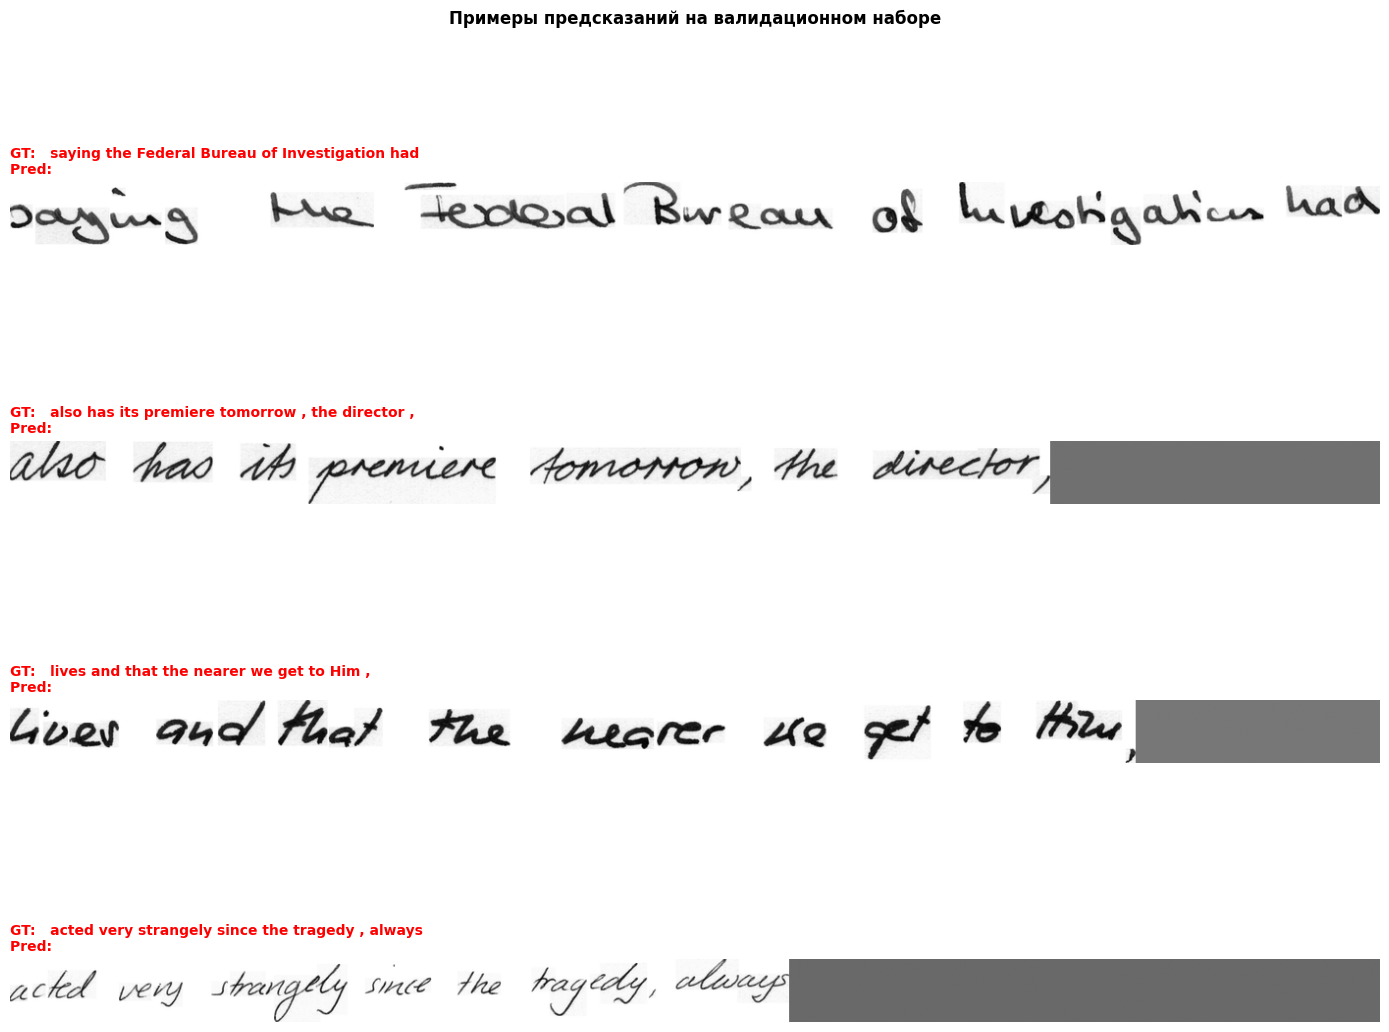


✓ Инференс завершён


In [41]:
# === Тестируем на валидационном наборе ===
model.eval()

# Возьмём батч из валидации
test_batch = next(iter(val_loader))

with torch.no_grad():
    images = test_batch['images'].to(device)
    outputs = model(images)
    predictions = decode_predictions(outputs, char_mapper)

# === Визуализируем результаты ===
fig, axes = plt.subplots(min(4, len(test_batch['texts'])), 1, 
                          figsize=(14, 3 * min(4, len(test_batch['texts']))))

if min(4, len(test_batch['texts'])) == 1:
    axes = [axes]

for i in range(min(4, len(test_batch['texts']))):
    ax = axes[i]
    
    # Получаем изображение
    img = test_batch['images'][i, 0].cpu().numpy()
    # Денормализуем: [-1, 1] → [0, 1]
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)
    
    ax.imshow(img, cmap='gray')
    
    gt = test_batch['texts'][i]
    pred = predictions[i]
    
    title = f"GT:   {gt}\nPred: {pred}"
    # Подсвечиваем зелёным если правильно, красным если нет
    color = 'green' if gt == pred else 'red'
    ax.set_title(title, fontsize=10, loc='left', color=color, weight='bold')
    ax.axis('off')

plt.suptitle('Примеры предсказаний на валидационном наборе', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Инференс завершён")


### Инференс: проверка работы модели

### Основной цикл обучения

### Функции обучения и валидации

### CRNN модель: CNN + BiLSTM

### Dataset и DataLoader

### Character Mapper: текст ↔ числа

### Исследование датасета и статистика